In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import pickle

print(os.getcwd())  # Should show the project root 

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs, PROPERTY_NAMES, REPRESENTATIVES_FOR_GOALS


%load_ext autoreload
%autoreload 2

/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/B_pca_and_pareto_trade-off


# All properties 

In [12]:
# Load data 
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
with open(output_folder / "all_datasets_filtered.pkl", "rb") as f:
    dict_with_all_datasets = pickle.load(f)
    
# Output of this script: pickle.dump(pca_df, open(output_folder / "pca_input_df.pkl", "wb"))

In [13]:
huge_df = pd.DataFrame()

# combine all the metrics into one dataframe for this experiment
for dataset_name, df in dict_with_all_datasets.items():
    # Add a column to identify the dataset
    df["dataset"] = dataset_name
    
    print(dataset_name, len(df["eta"]))
    # Remove this, as eta, gamma, etc are not defined here? 
    if dataset_name == "kaysons_generated_networks_topology": 
        print(" ---> skipped")
        continue
    huge_df = pd.concat([huge_df, df], ignore_index=True)
    
    
# Remove any rows in huge_df that are completely empty 
huge_df.dropna(how="all", inplace=True)

hcp_schaefer_100_dataset_gnm 25000
hcp_schaefer_100_dataset 100
kaysons_generated_networks_diffusion 1
kaysons_generated_networks_propagation 1
kaysons_generated_networks_routing 1
kaysons_generated_networks_topology 2
 ---> skipped
suarez_MaMI_dataset 224


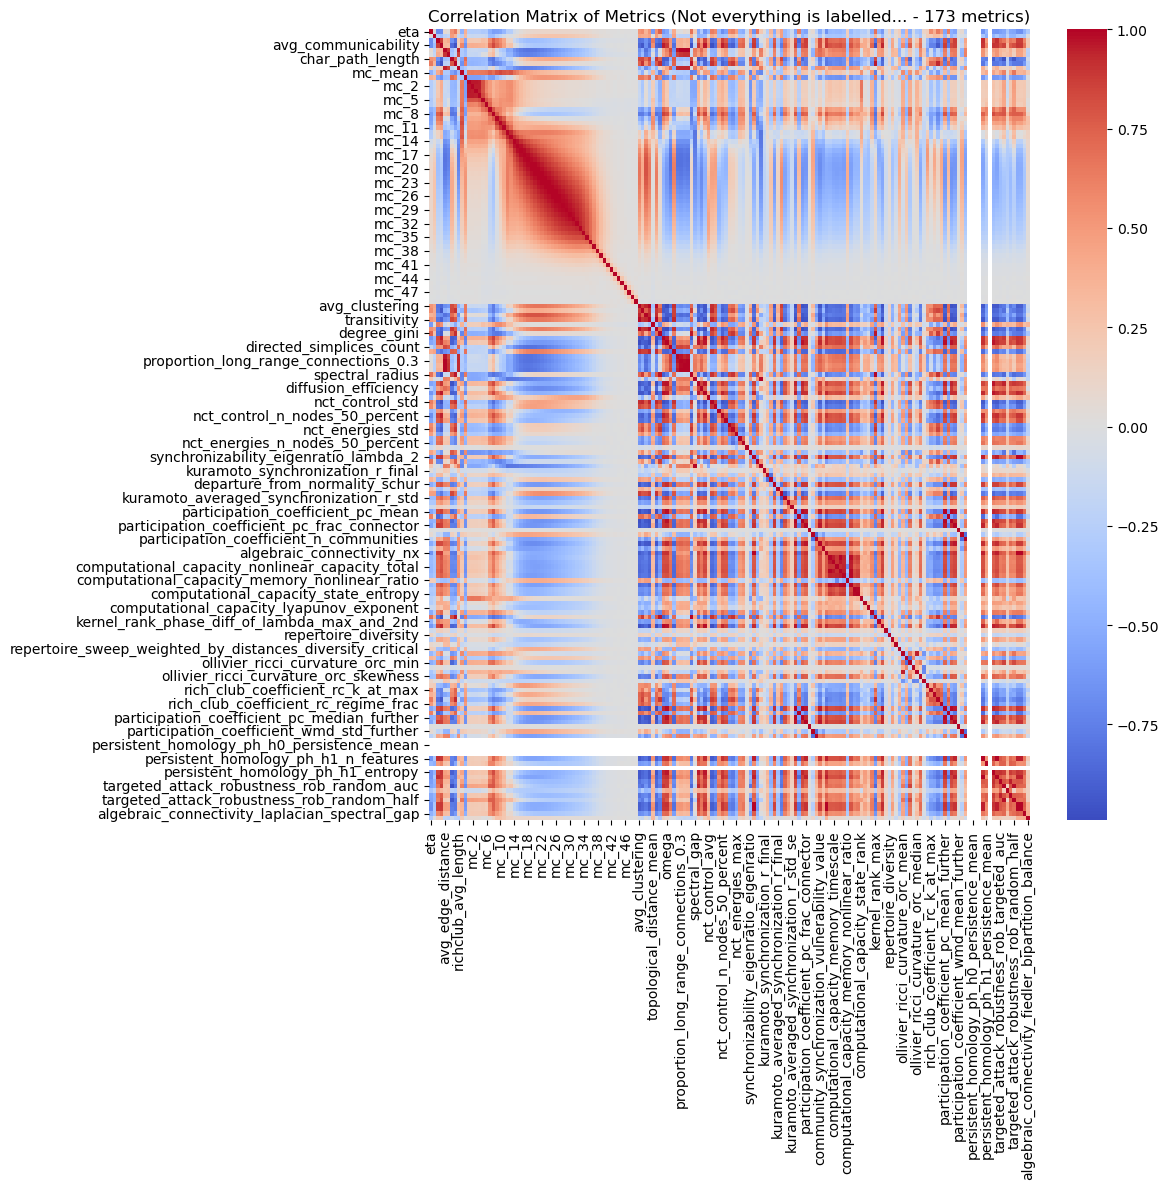

In [15]:
# For pca always drop the dataset column and only use the metric columns
huge_df_properties = huge_df.drop(columns=["dataset", "id"]) if "dataset" in huge_df.keys() else huge_df.drop(columns=["id"])

# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df_properties.corr() if "dataset" not in huge_df_properties.keys() else huge_df_properties.drop(columns=["dataset"]).corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=False, # fmt=".2f", 
            cmap="coolwarm", cbar=True)
plt.title(f"Correlation Matrix of Metrics (Not everything is labelled... - {correlation_matrix.shape[0]} metrics)")
plt.tight_layout()
plt.show()
# Not everything is labelled... 

Dropped columns: ['repertoire_size', 'repertoire_diversity']


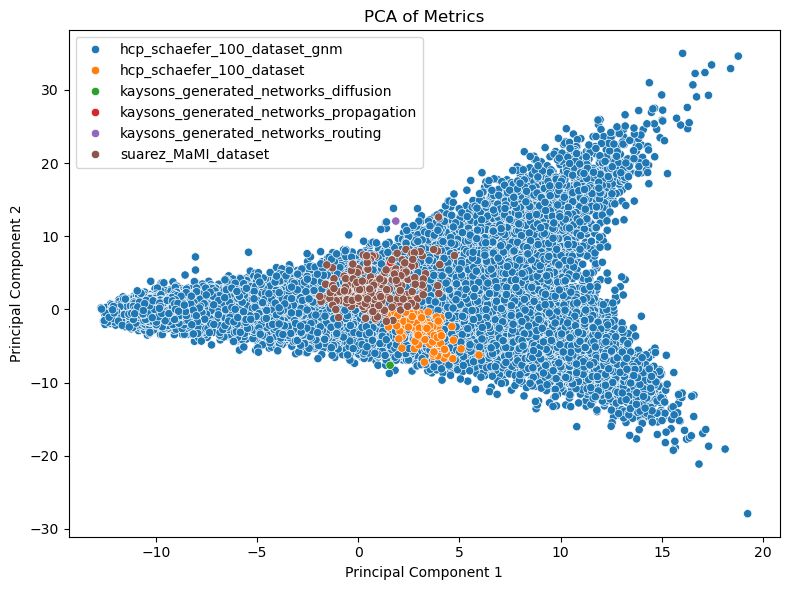

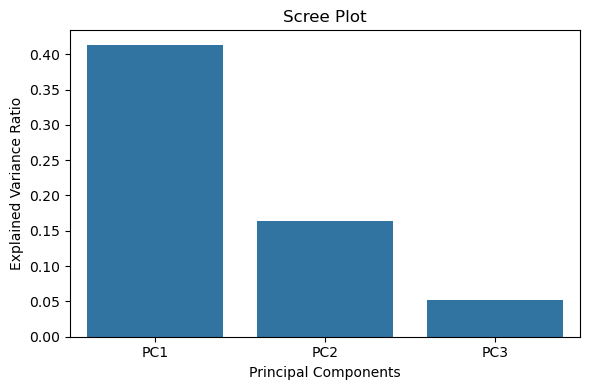

In [16]:
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# # print all max values of all columns in huge_df_metrics
# print("\nMax values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].max():.4f}")
# print("\nMin values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].min():.4f}")
    
# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=3) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=huge_df['dataset'])
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()

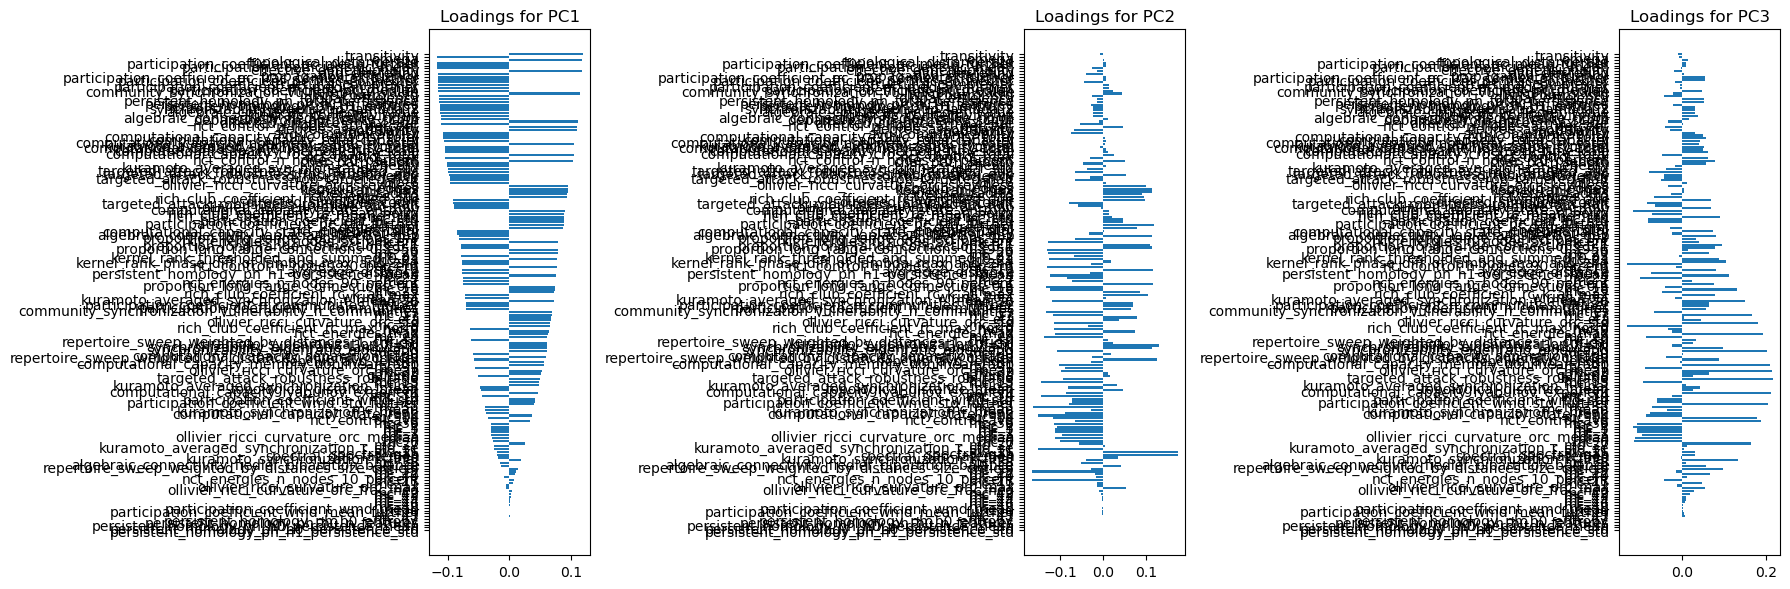

In [17]:
# Subplots of loadings for the first 3 principal components
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()



# Selected properties 

In [5]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")
output_folder.mkdir(exist_ok=True)

# Load data 
with open(output_folder / "pca_input_df.pkl", "rb") as f:
    pca_input_df_label = pickle.load(f)


pca_input_df = pca_input_df_label.drop(columns="dataset")
pca_input_df = pca_input_df.drop(columns=["eta", 
                                          "gamma", 
                                          "mc_15", 
                                          "wiring_cost"])

# Folder now changed for saving 
output_folder = output_folder / "pca_results"
output_folder.mkdir(exist_ok=True)


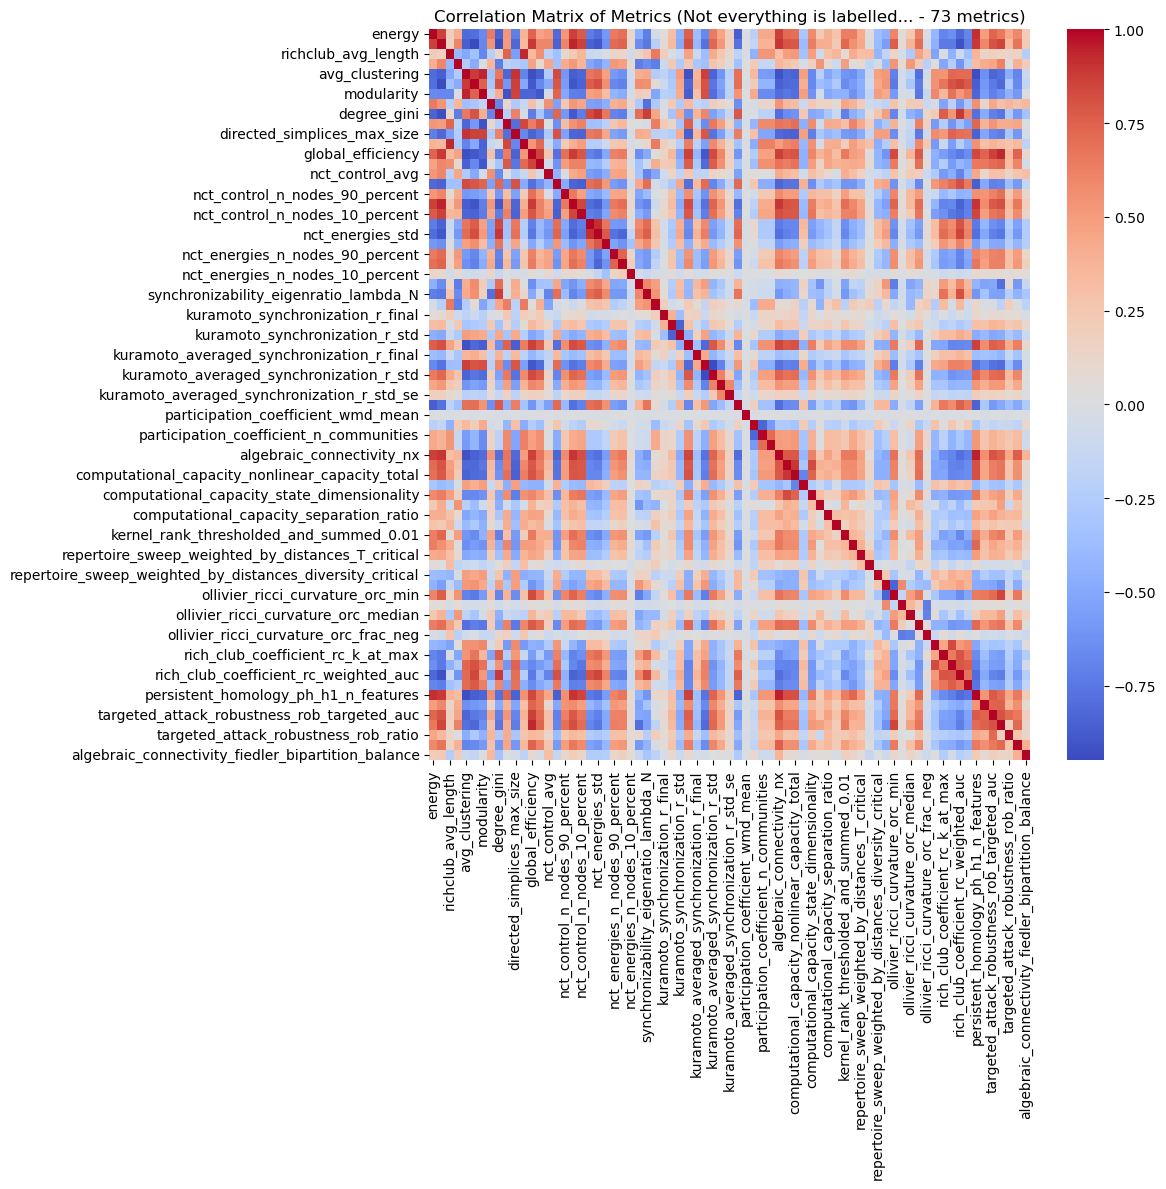

In [6]:
# For pca always drop the dataset column and only use the metric columns
huge_df_properties = pca_input_df # pca_input_df.drop(columns=["dataset", "id"]) if "dataset" in pca_input_df.keys() else pca_input_df.drop(columns=["id"])

# Make a correlation axis between the columns of the huge_df. Don't use the dataset column for this, only the metric columns.
correlation_matrix = huge_df_properties.corr() if "dataset" not in huge_df_properties.keys() else huge_df_properties.drop(columns=["dataset"]).corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=False, # fmt=".2f", 
            cmap="coolwarm", cbar=True)
plt.title(f"Correlation Matrix of Metrics (Not everything is labelled... - {correlation_matrix.shape[0]} metrics)")
plt.tight_layout()
plt.show()


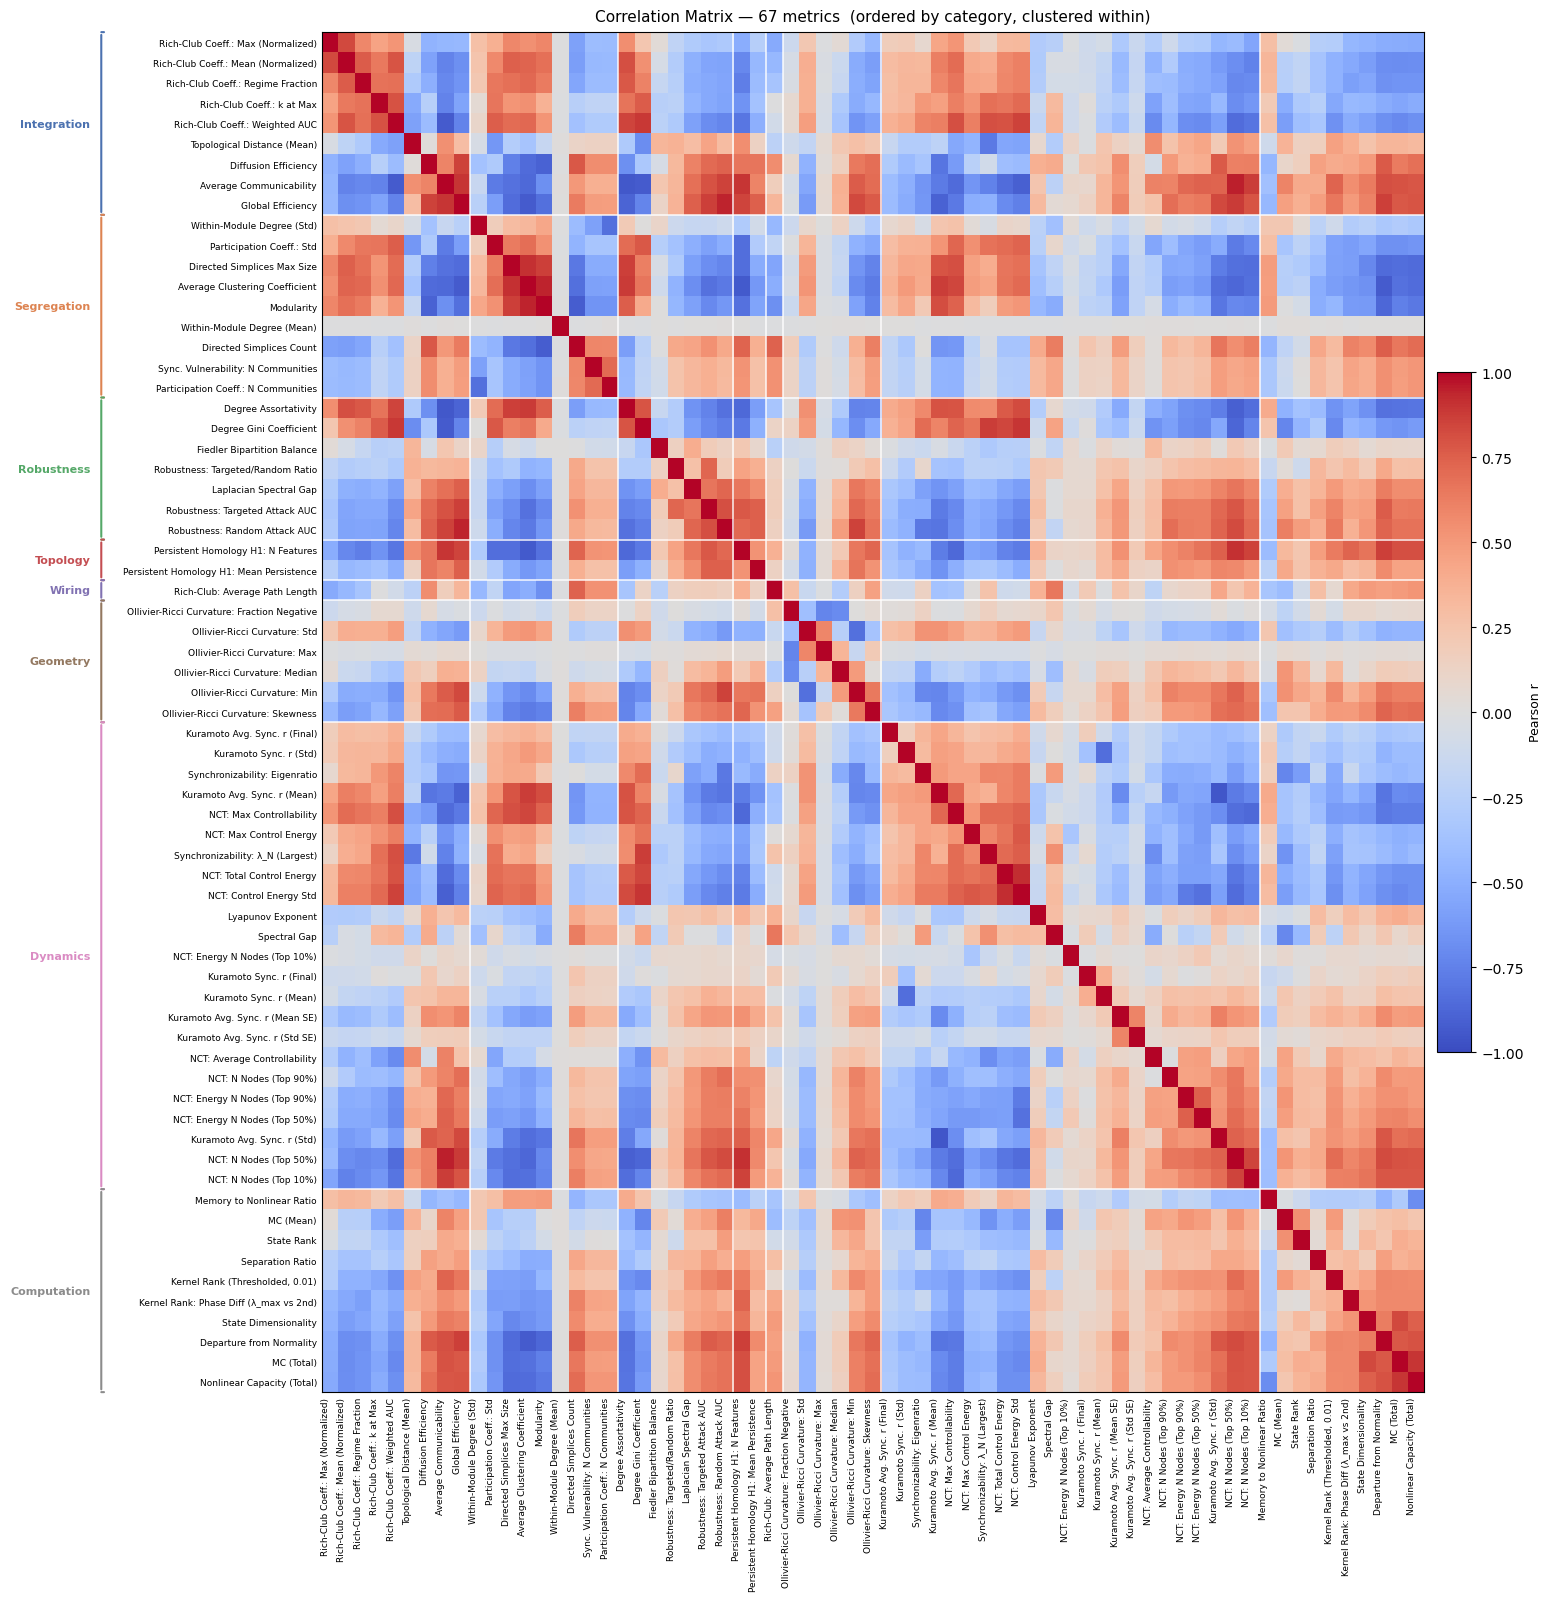

Saved: corr_matrix_categorised.pdf


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# ── 1. Load category / section metadata from Excel ────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx" # network_properties_full_excel.xlsx"   # ← adjust path if needed
meta_raw = pd.read_excel(excel_path, sheet_name=0)

# Forward-fill the section headers (rows where 'Variable Name' is NaN)
meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

# Keep only actual variable rows
meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)

# Preferred display order for broad categories
CATEGORY_ORDER = [
    "Integration", "Segregation", "Robustness",
    "Topology", "Wiring", "Geometry",
    "Dynamics", "Computation",
]

# Colour palette — one colour per broad category
CATEGORY_COLOURS = {
    "Integration":  "#4C72B0",
    "Segregation":  "#DD8452",
    "Robustness":   "#55A868",
    "Topology":     "#C44E52",
    "Wiring":       "#8172B2",
    "Geometry":     "#937860",
    "Dynamics":     "#DA8BC3",
    "Computation":  "#8C8C8C",
}

# ── 2. Filter to only the variables present in your reduced_corr ──────────────
# (replace `remaining_cols` and `huge_df` with your actual variable names / df)
cols_in_data = [c for c in huge_df_properties.keys() if c in meta.index]

# Assign a sort key: primary = category order index, secondary = section string
def sort_key(col):
    row = meta.loc[col]
    cat = row["Category"] if pd.notna(row["Category"]) else "ZZZ"
    cat_idx = CATEGORY_ORDER.index(cat) if cat in CATEGORY_ORDER else len(CATEGORY_ORDER)
    return (cat_idx, str(row["section"]))

cols_sorted_by_cat = sorted(cols_in_data, key=sort_key)

# ── 3. Within-category hierarchical clustering ────────────────────────────────
corr_full = pca_input_df.corr() # huge_df[cols_in_data].corr()

final_order = []
for cat in CATEGORY_ORDER:
    cat_cols = [c for c in cols_sorted_by_cat if meta.loc[c, "Category"] == cat]
    if len(cat_cols) == 0:
        continue
    if len(cat_cols) == 1:
        final_order.extend(cat_cols)
        continue

    sub_corr = corr_full.loc[cat_cols, cat_cols].fillna(0)
    # Convert correlation to distance; clip to avoid numerical issues
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
    final_order.extend([cat_cols[i] for i in order])

# Variables not assigned a known category — append at end
uncategorised = [c for c in cols_in_data if c not in final_order]
final_order.extend(uncategorised)

# ── 4. Reorder correlation matrix ─────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]

# ── 5. Build display labels (use PROPERTY_NAMES where available) ──────────────
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 6. Build category colour arrays for the side-bar ─────────────────────────
bar_colours = []
for c in final_order:
    cat = meta.loc[c, "Category"] if c in meta.index else None
    bar_colours.append(CATEGORY_COLOURS.get(cat, "#CCCCCC"))

# ── 7. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig_size = max(16, n * 0.22)
fig = plt.figure(figsize=(fig_size + 1.5, fig_size))

# Single axes — brackets will be drawn to the left in axes/figure coordinates
gs = gridspec.GridSpec(
    1, 1,
    left=0.22, right=0.97,
    top=0.97, bottom=0.12,
)

ax_heat = fig.add_subplot(gs[0])

# — Heatmap —
im = ax_heat.imshow(
    reduced_corr.values,
    cmap="coolwarm", vmin=-1, vmax=1,
    aspect="auto", interpolation="none",
)

# Draw thin white lines between categories to visually separate them
boundaries = [0]
prev_cat = meta.loc[final_order[0], "Category"] if final_order[0] in meta.index else None
for i, c in enumerate(final_order[1:], start=1):
    curr_cat = meta.loc[c, "Category"] if c in meta.index else None
    if curr_cat != prev_cat:
        boundaries.append(i)
        prev_cat = curr_cat
boundaries.append(n)

for b in boundaries[1:-1]:
    ax_heat.axhline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)
    ax_heat.axvline(b - 0.5, color="white", linewidth=1.2, alpha=0.85)

# Tick labels
ax_heat.set_xticks(np.arange(n))
ax_heat.set_xticklabels(new_labels, rotation=90, fontsize=6.5, ha="right")
ax_heat.set_yticks(np.arange(n))
ax_heat.set_yticklabels(new_labels, fontsize=6.5)
ax_heat.tick_params(axis="both", which="both", length=0)

# ── Draw category brackets to the left of y-tick labels ──────────────────────
# We work in axes coordinates (0-1 in both x and y).
# y=0 is bottom of axes, y=1 is top; row 0 (first variable) is at the TOP.

# Build a map: category → (first_row_index, last_row_index)  [0-based, top-down]
cat_row_spans = {}
for row_i, c in enumerate(final_order):
    cat = meta.loc[c, "Category"] if c in meta.index else "Other"
    if cat not in cat_row_spans:
        cat_row_spans[cat] = [row_i, row_i]
    else:
        cat_row_spans[cat][1] = row_i

def row_to_axes_y(row_i, n):
    """Convert a 0-based top-down row index to matplotlib axes y coordinate."""
    # imshow row 0 is plotted at y = (n-0.5)/n  →  top
    return 1.0 - (row_i + 0.5) / n

BRACKET_X   = -0.2 # -0.015   # axes x where the vertical bar of the bracket sits
TICK_OFFSET = -0.005   # small horizontal serifs
LABEL_X     = -0.21 # -0.025   # axes x for the category name text

trans = ax_heat.transAxes  # all coordinates in axes fraction

for cat, (r_first, r_last) in cat_row_spans.items():
    colour = CATEGORY_COLOURS.get(cat, "#444444")
    y_top    = row_to_axes_y(r_first, n) + 0.5 / n   # top edge of first row
    y_bottom = row_to_axes_y(r_last,  n) - 0.5 / n   # bottom edge of last row
    y_mid    = (y_top + y_bottom) / 2

    # Vertical bar
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Top serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_top), xytext=(BRACKET_X - TICK_OFFSET, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Bottom serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X - TICK_OFFSET, y_bottom),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.5),
        annotation_clip=False,
    )
    # Category label
    ax_heat.text(
        LABEL_X, y_mid, cat,
        transform=trans,
        ha="right", va="center",
        fontsize=8, fontweight="bold",
        color=colour,
        clip_on=False,
    )

# Colour-bar legend
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)

ax_heat.set_title(
    f"Correlation Matrix — {n} metrics  (ordered by category, clustered within)",
    fontsize=11, pad=8,
)

plt.savefig("corr_matrix_categorised.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: corr_matrix_categorised.pdf")

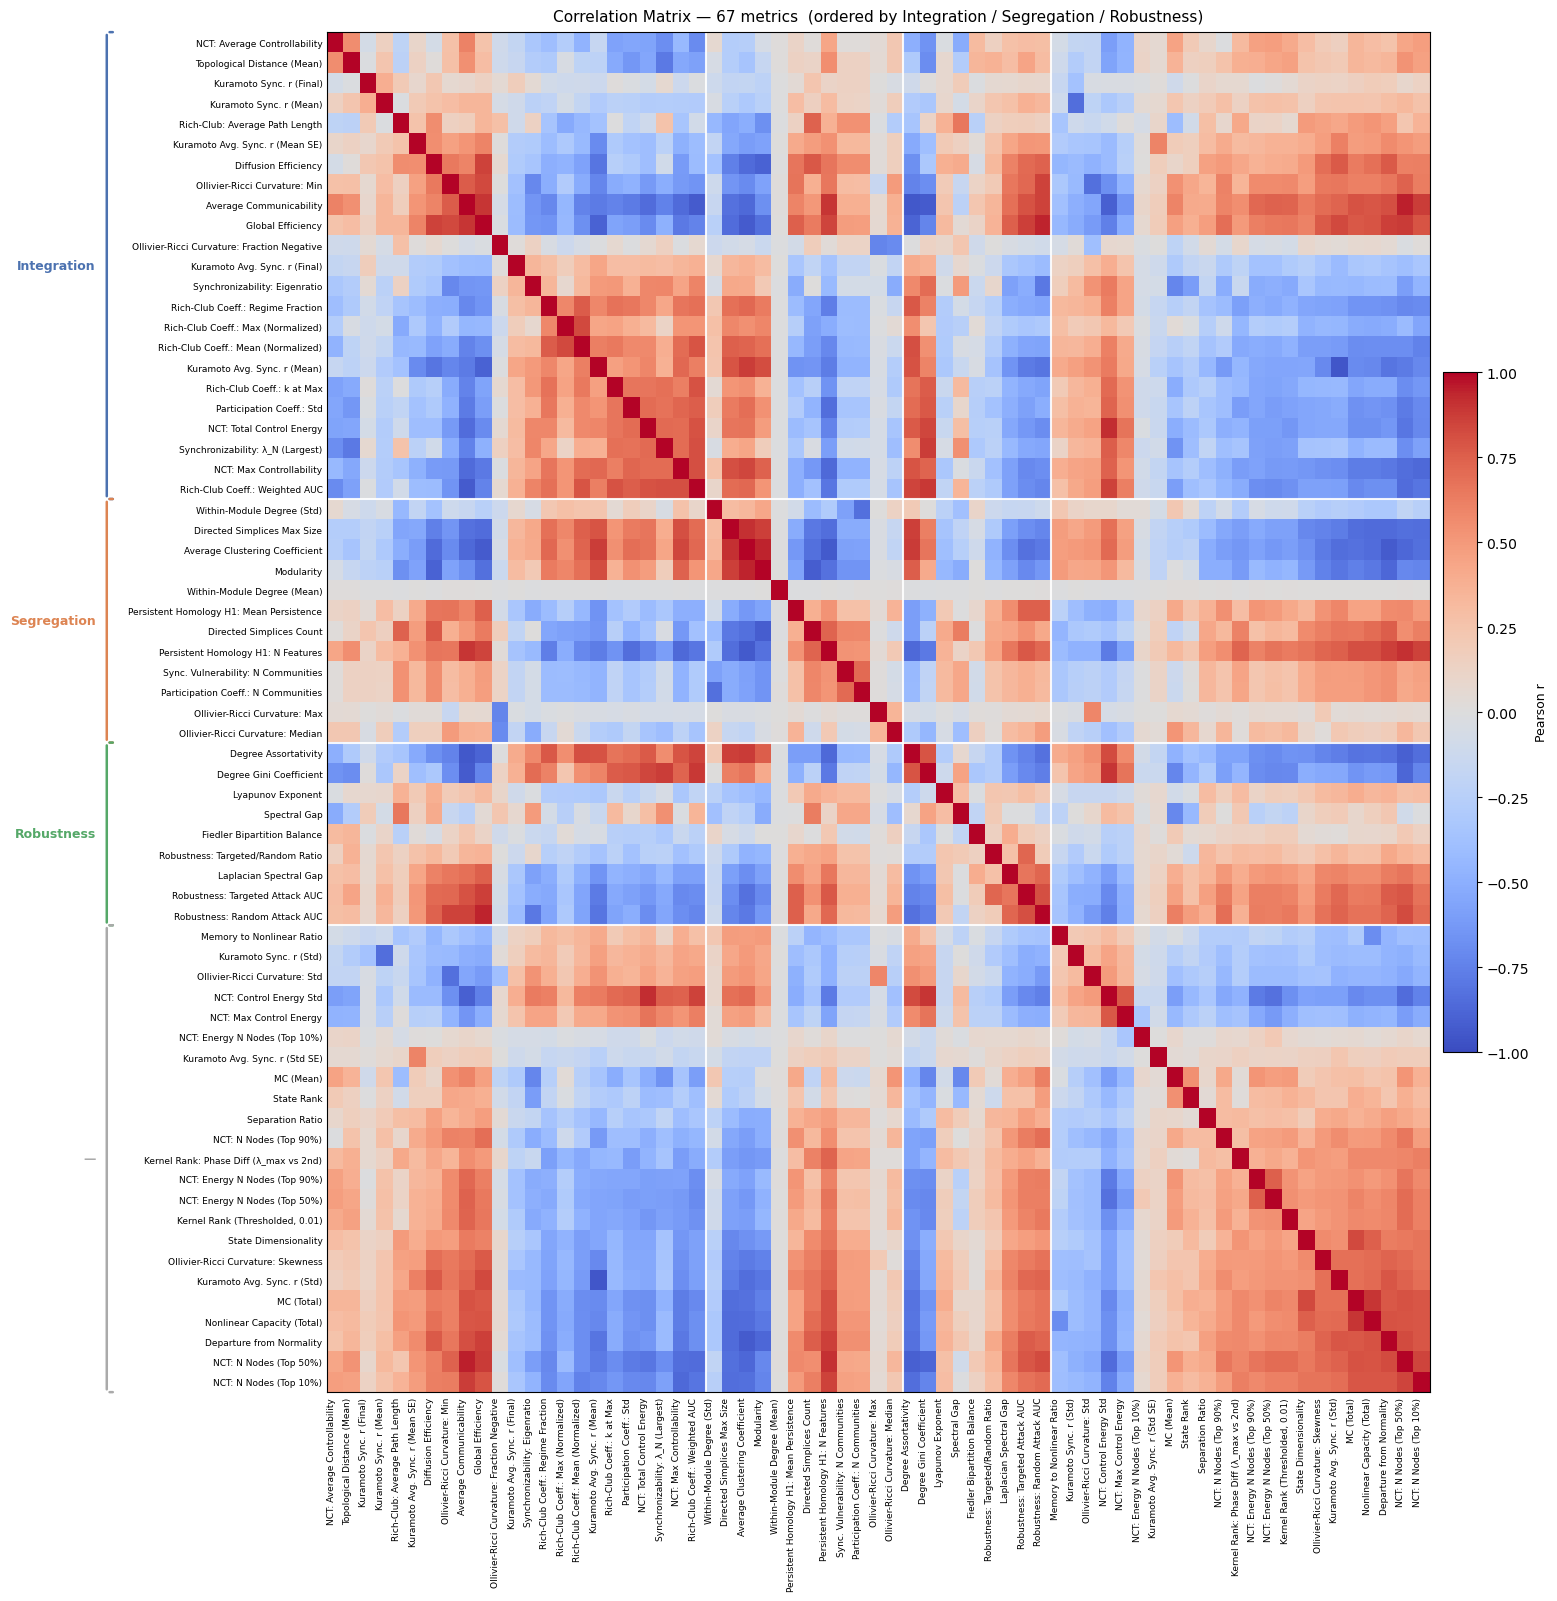

Saved: corr_matrix_integsegrob.pdf


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# ── 1. Load metadata from Excel ───────────────────────────────────────────────
excel_path = "/Users/adrian/Desktop/network_properties_full_excel.xlsx"
meta_raw = pd.read_excel(excel_path, sheet_name=0)

# Forward-fill the section headers (rows where 'Variable Name' is NaN)
meta_raw["section"] = meta_raw.apply(
    lambda r: r["#"] if pd.isna(r["Variable Name"]) and pd.notna(r["#"]) else None,
    axis=1,
).ffill()

# Keep only actual variable rows; bring in BOTH classification columns
meta = (
    meta_raw[meta_raw["Variable Name"].notna()]
    [["Variable Name", "Category", "Integ/Segr/Rob", "section"]]
    .rename(columns={"Variable Name": "var"})
    .set_index("var")
)

# ── Classification column to use for ordering & brackets ─────────────────────
# Switch between "Category" and "Integ/Segr/Rob" here:
CLASS_COL = "Integ/Segr/Rob"

# "—" means unclassified; treat it as a separate group at the end
UNCLASSIFIED_LABEL = "—"

# Preferred display order for the Integ/Segr/Rob groups
CLASS_ORDER = ["Integration", "Segregation", "Robustness", UNCLASSIFIED_LABEL]

CLASS_COLOURS = {
    "Integration":  "#4C72B0",
    "Segregation":  "#DD8452",
    "Robustness":   "#55A868",
    UNCLASSIFIED_LABEL: "#AAAAAA",
}

# ── 2. Filter to variables present in your dataframe ──────────────────────────
cols_in_data = [c for c in huge_df_properties.keys() if c in meta.index]

def get_class(col):
    val = meta.loc[col, CLASS_COL]
    return val if pd.notna(val) else UNCLASSIFIED_LABEL

# Sort key: primary = CLASS_ORDER index, secondary = section (keeps related
# metrics together before within-group clustering)
def sort_key(col):
    cls = get_class(col)
    cls_idx = CLASS_ORDER.index(cls) if cls in CLASS_ORDER else len(CLASS_ORDER)
    return (cls_idx, str(meta.loc[col, "section"]))

cols_sorted = sorted(cols_in_data, key=sort_key)

# ── 3. Within-group hierarchical clustering ───────────────────────────────────
corr_full = pca_input_df[cols_in_data].corr()

final_order = []
for cls in CLASS_ORDER:
    cls_cols = [c for c in cols_sorted if get_class(c) == cls]
    if len(cls_cols) == 0:
        continue
    if len(cls_cols) == 1:
        final_order.extend(cls_cols)
        continue

    sub_corr = corr_full.loc[cls_cols, cls_cols].fillna(0)
    dist = np.clip(1 - sub_corr.values, 0, 2)
    np.fill_diagonal(dist, 0)
    condensed = squareform(dist, checks=False)
    Z = linkage(condensed, method="average")
    order = leaves_list(Z)
    final_order.extend([cls_cols[i] for i in order])

# Variables not matched to any class — append at end
uncategorised = [c for c in cols_in_data if c not in final_order]
final_order.extend(uncategorised)

# ── 4. Reorder correlation matrix ─────────────────────────────────────────────
reduced_corr = corr_full.loc[final_order, final_order]

# ── 5. Build display labels ───────────────────────────────────────────────────
new_labels = [PROPERTY_NAMES.get(c, c) for c in final_order]

# ── 6. Plot ───────────────────────────────────────────────────────────────────
n = len(final_order)
fig_size = max(16, n * 0.22)
fig = plt.figure(figsize=(fig_size + 1.5, fig_size))

gs = gridspec.GridSpec(
    1, 1,
    left=0.22, right=0.97,
    top=0.97, bottom=0.12,
)
ax_heat = fig.add_subplot(gs[0])

# — Heatmap —
im = ax_heat.imshow(
    reduced_corr.values,
    cmap="coolwarm", vmin=-1, vmax=1,
    aspect="auto", interpolation="none",
)

# White separator lines between groups
boundaries = [0]
prev_cls = get_class(final_order[0])
for i, c in enumerate(final_order[1:], start=1):
    curr_cls = get_class(c)
    if curr_cls != prev_cls:
        boundaries.append(i)
        prev_cls = curr_cls
boundaries.append(n)

for b in boundaries[1:-1]:
    ax_heat.axhline(b - 0.5, color="white", linewidth=1.5, alpha=0.9)
    ax_heat.axvline(b - 0.5, color="white", linewidth=1.5, alpha=0.9)

# Tick labels
ax_heat.set_xticks(np.arange(n))
ax_heat.set_xticklabels(new_labels, rotation=90, fontsize=6.5, ha="right")
ax_heat.set_yticks(np.arange(n))
ax_heat.set_yticklabels(new_labels, fontsize=6.5)
ax_heat.tick_params(axis="both", which="both", length=0)

# ── Draw brackets to the left of y-tick labels ────────────────────────────────
cls_row_spans = {}
for row_i, c in enumerate(final_order):
    cls = get_class(c)
    if cls not in cls_row_spans:
        cls_row_spans[cls] = [row_i, row_i]
    else:
        cls_row_spans[cls][1] = row_i

def row_to_axes_y(row_i, n):
    return 1.0 - (row_i + 0.5) / n

BRACKET_X   = -0.20   # x position of vertical bar  (axes fraction)
SERIF_W     =  -0.008  # half-width of top/bottom serifs
LABEL_X     = -0.21   # x position of label text

trans = ax_heat.transAxes

for cls, (r_first, r_last) in cls_row_spans.items():
    colour  = CLASS_COLOURS.get(cls, "#444444")
    y_top    = row_to_axes_y(r_first, n) + 0.5 / n
    y_bottom = row_to_axes_y(r_last,  n) - 0.5 / n
    y_mid    = (y_top + y_bottom) / 2

    # Vertical bar
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.8),
        annotation_clip=False,
    )
    # Top serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_top), xytext=(BRACKET_X - SERIF_W, y_top),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.8),
        annotation_clip=False,
    )
    # Bottom serif
    ax_heat.annotate(
        "", xy=(BRACKET_X, y_bottom), xytext=(BRACKET_X - SERIF_W, y_bottom),
        xycoords=trans, textcoords=trans,
        arrowprops=dict(arrowstyle="-", color=colour, lw=1.8),
        annotation_clip=False,
    )
    # Label
    ax_heat.text(
        LABEL_X, y_mid, cls,
        transform=trans,
        ha="right", va="center",
        fontsize=9, fontweight="bold",
        color=colour,
        clip_on=False,
    )

# Colorbar
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.5, pad=0.01)
cbar.set_label("Pearson r", fontsize=9)

ax_heat.set_title(
    f"Correlation Matrix — {n} metrics  (ordered by Integration / Segregation / Robustness)",
    fontsize=11, pad=8,
)

plt.savefig("corr_matrix_integsegrob.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: corr_matrix_integsegrob.pdf")

In [12]:

# Not everything is labelled... 
# Create a PCA between the columns of the huge_df
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# # print all max values of all columns in huge_df_metrics
# print("\nMax values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].max():.4f}")
# print("\nMin values of metrics:")
# for col in huge_df_metrics.columns:
#     print(f"{col}: {huge_df_metrics[col].min():.4f}")
    
# Drop the columns that have inf or -inf values (if any). Print the dropped columns
dropped_cols = huge_df_properties.columns[huge_df_properties.isnull().any()].tolist()
huge_df_properties.replace([np.inf, -np.inf], np.nan, inplace=True)
huge_df_properties.dropna(axis=1, inplace=True)
print(f"Dropped columns: {dropped_cols}")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(huge_df_properties)

pca = PCA(n_components=10) # 3) # 10)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=pca_input_df['dataset'])
plt.title("PCA of Metrics")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

# Scree plot to show explained variance
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6,4))
sns.barplot(x=[f"PC{i+1}" for i in range(len(explained_variance))], y=explained_variance)
plt.title("Scree Plot")
plt.ylabel("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.tight_layout()
plt.show()
# Subplots of loadings for the first 3 principal components
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


Dropped columns: []


KeyError: 'dataset'

<Figure size 800x600 with 0 Axes>

In [ ]:
huge_df_properties.columns

Index(['energy', 'avg_communicability', 'richclub_avg_length', 'mc_mean',
       'avg_clustering', 'degree_assortativity', 'modularity',
       'topological_distance_mean', 'degree_gini', 'directed_simplices_count',
       'directed_simplices_max_size',
       'proportion_long_range_connections_0.3956', 'global_efficiency',
       'diffusion_efficiency', 'nct_control_avg', 'nct_control_max',
       'nct_control_n_nodes_90_percent', 'nct_control_n_nodes_50_percent',
       'nct_control_n_nodes_10_percent', 'nct_energies_total',
       'nct_energies_std', 'nct_energies_max',
       'nct_energies_n_nodes_90_percent', 'nct_energies_n_nodes_50_percent',
       'nct_energies_n_nodes_10_percent',
       'synchronizability_eigenratio_eigenratio',
       'synchronizability_eigenratio_lambda_N', 'spectral_gap_fatemeh',
       'kuramoto_synchronization_r_final', 'kuramoto_synchronization_r_mean',
       'kuramoto_synchronization_r_std', 'departure_from_normality_schur',
       'kuramoto_averaged_

In [83]:
# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

print("Top 30 contributors to PC1:")
for i in range(30):
    print(f"     {metric_names[i]}") # : {loadings[i, 0]:.4f}")

Top 30 contributors to PC1:
     participation_coefficient_wmd_mean
     ollivier_ricci_curvature_orc_frac_neg
     spectral_gap_fatemeh
     ollivier_ricci_curvature_orc_max
     repertoire_sweep_weighted_by_distances_size_critical
     nct_energies_n_nodes_10_percent
     kuramoto_synchronization_r_final
     algebraic_connectivity_fiedler_bipartition_balance
     kuramoto_averaged_synchronization_r_std_se
     participation_coefficient_wmd_std
     ollivier_ricci_curvature_orc_median
     computational_capacity_lyapunov_exponent
     kuramoto_synchronization_r_mean
     computational_capacity_state_rank
     richclub_avg_length
     targeted_attack_robustness_rob_ratio
     kuramoto_averaged_synchronization_r_final
     nct_control_avg
     computational_capacity_memory_nonlinear_ratio
     mc_mean
     topological_distance_mean
     repertoire_sweep_weighted_by_distances_diversity_critical
     computational_capacity_separation_ratio
     repertoire_sweep_weighted_by_distances_T_cr

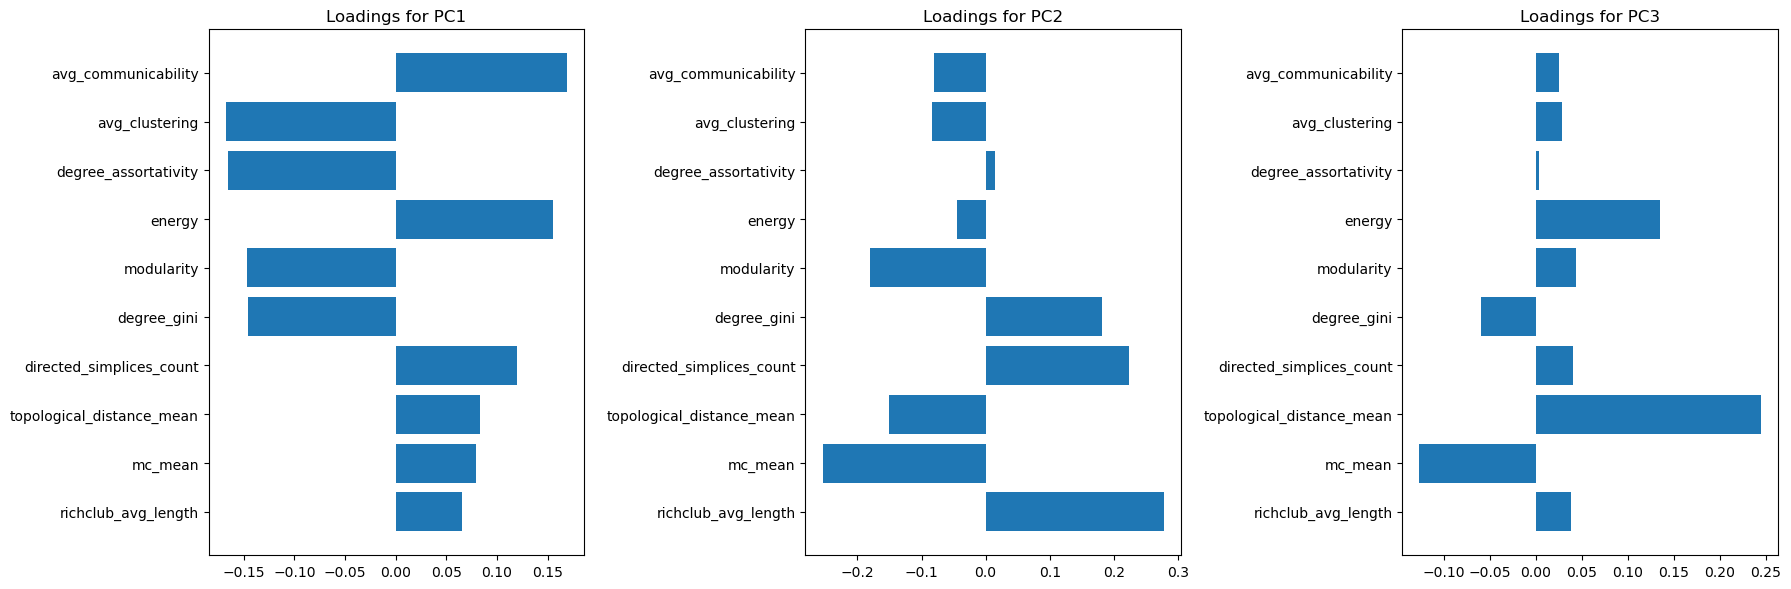

In [84]:

# Subplots of loadings for the first 3 principal components, ONLY top 10 contributors
loadings = pca.components_.T[:10, :]
num_metrics = loadings.shape[0]
metric_names = huge_df_properties.columns

# order them all by the absolute value of their loading on the first principal component
sorted_indices = np.argsort(np.abs(loadings[:, 0])) #[::-1]
loadings = loadings[sorted_indices]
metric_names = metric_names[sorted_indices]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(3):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")
plt.tight_layout()
plt.show()


In [107]:
REPRESENTATIVES_FOR_GOALS

{'mc_mean': 'Capacity (Memory)',
 'modularity': 'Segregation',
 'proportion_long_range_connections_0.3956': 'Wiring Economy',
 'global_efficiency': 'Integration',
 'synchronizability_eigenratio_eigenratio': 'Synchronizability: Eigenratio',
 'kuramoto_synchronization_r_std': 'Kuramoto: Std',
 'algebraic_connectivity_nx': 'Robustness',
 'computational_capacity_nonlinear_capacity_total': 'Capacity (Nonlinear Computation)',
 'repertoire_sweep_weighted_by_distances_diversity_critical': 'Metastability (Repertoire Diversity)',
 'targeted_attack_robustness_rob_targeted_auc': 'Robustness (Targeted Attack)'}

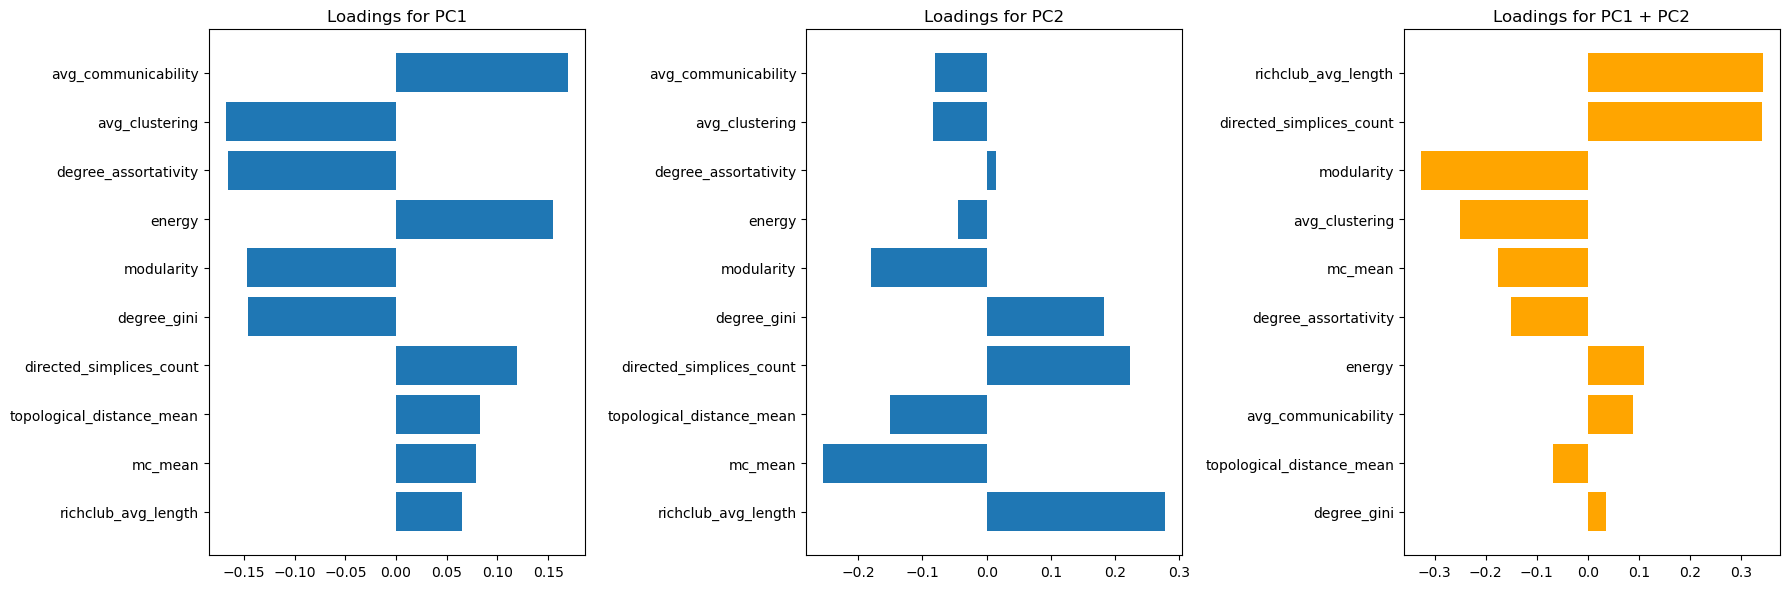

In [85]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
for i in range(2):
    axs[i].barh(range(num_metrics), loadings[:, i])
    axs[i].set_yticks(range(num_metrics))
    axs[i].set_yticklabels(metric_names, rotation=0)
    axs[i].set_title(f"Loadings for PC{i+1}")

# Plot 3: Addition of PC1 and PC2, ordered by magnitude of PC1+PC2
ordered_pc1_plus_pc2_indices = np.argsort(np.abs(loadings[:, 0] + loadings[:, 1])) #[::-1]
loadings = loadings[ordered_pc1_plus_pc2_indices]
metric_names = metric_names[ordered_pc1_plus_pc2_indices]
axs[2].barh(range(num_metrics), loadings[:, 0] + loadings[:, 1], color="orange")
axs[2].set_yticks(range(num_metrics))
axs[2].set_yticklabels(metric_names, rotation=0)
axs[2].set_title("Loadings for PC1 + PC2")

plt.tight_layout()
plt.show()

Corner points:
  top_left: index=11126, PC1=-11.37, PC2=13.97, dataset=hcp_schaefer_100_dataset_gnm
  bottom_left: index=2031, PC1=-9.63, PC2=-3.50, dataset=hcp_schaefer_100_dataset_gnm
  bottom_right: index=8358, PC1=9.17, PC2=-1.34, dataset=hcp_schaefer_100_dataset_gnm


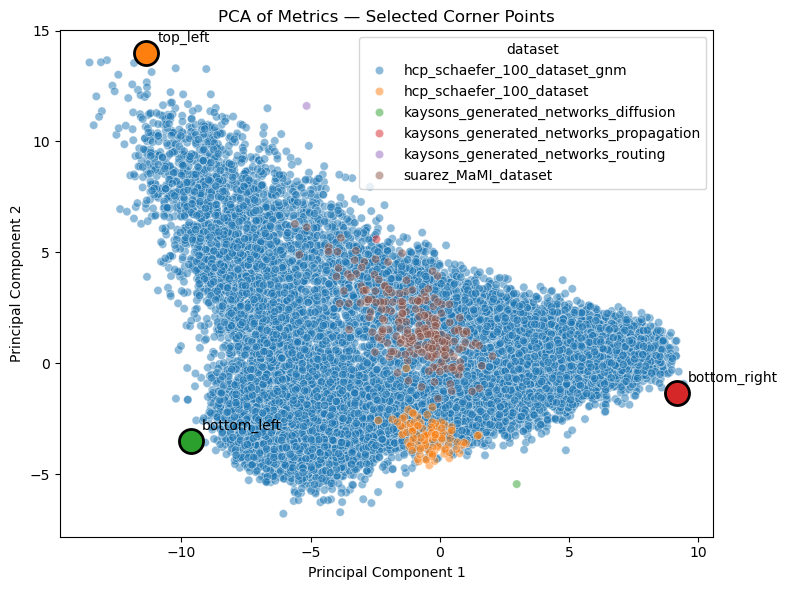

In [86]:
# ── STEP 1: Find the 3 extreme corner points ──────────────────────────────────


# For pca always drop the dataset column and only use the metric columns
# pca_df_with_dataset_label = huge_df[remaining_cols+["dataset"]]
pca_df = pca_input_df_label.drop(columns="dataset") 

corners = {
    "top_left":    np.argmax(pca_result[:, 1]),                              # max PC2
    "bottom_left": np.argmax(-pca_result[:, 0] - pca_result[:, 1]),         # min PC1 + min PC2
    # "right":       np.argmax(pca_result[:, 0]),       # max PC1
    "bottom_right": np.argmax(pca_result[:, 0] - pca_result[:, 1]),         # max PC1 + min PC2
}

print("Corner points:")
for name, idx in corners.items():
    print(f"  {name}: index={idx}, PC1={pca_result[idx,0]:.2f}, PC2={pca_result[idx,1]:.2f}, "
          f"dataset={pca_input_df_label['dataset'].iloc[idx]}")

# Verify visually
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=pca_input_df_label['dataset'], alpha=0.5)
for name, idx in corners.items():
    plt.scatter(pca_result[idx, 0], pca_result[idx, 1], s=300, zorder=5, edgecolors='black', linewidths=2)
    plt.annotate(name, (pca_result[idx, 0], pca_result[idx, 1]), textcoords="offset points", xytext=(8, 8), fontsize=10)
plt.title("PCA of Metrics — Selected Corner Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()


In [87]:
# ── STEP 2: Get the top 6 features by loading magnitude (PC1 + PC2) ───────────

feature_names = pca_df.columns  # from your pipeline: pca_df = pca_df_with_dataset_label.drop(columns="dataset")
loading_magnitude = np.sqrt(pca.components_[0]**2 + pca.components_[1]**2)
top6_idx = np.argsort(loading_magnitude)[::-1][:6]
top6_features = feature_names[top6_idx]

print("\nTop 6 features by PC1+PC2 loading magnitude:")
for feat, mag in zip(top6_features, loading_magnitude[top6_idx]):
    print(f"  {feat}: {mag:.4f}")

# ── STEP 3: Extract standardized values for each corner ───────────────────────

corner_data = {
    name: scaled_data[idx, top6_idx]
    for name, idx in corners.items()
}



Top 6 features by PC1+PC2 loading magnitude:
  nct_energies_n_nodes_50_percent: 0.3144
  energy: 0.2856
  topological_distance_mean: 0.2824
  avg_communicability: 0.2664
  degree_assortativity: 0.2529
  nct_energies_n_nodes_90_percent: 0.2438


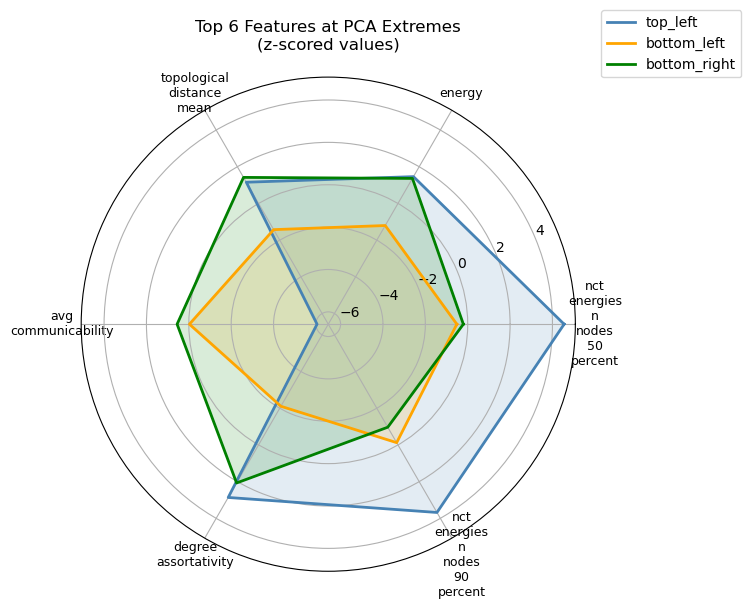

In [88]:

# ── STEP 4: Spider plot ────────────────────────────────────────────────────────

labels = [f.replace("_", "\n") for f in top6_features]  # wrap long names
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

colors = {"top_left": "steelblue", 
          "bottom_left": "orange", 
          "right": "brown", 
          "bottom_right": "green"
          }  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, values in corner_data.items():
    vals = values.tolist() + [values[0]]
    ax.plot(angles, vals, label=name, color=colors[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=colors[name])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_title("Top 6 Features at PCA Extremes\n(z-scored values)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

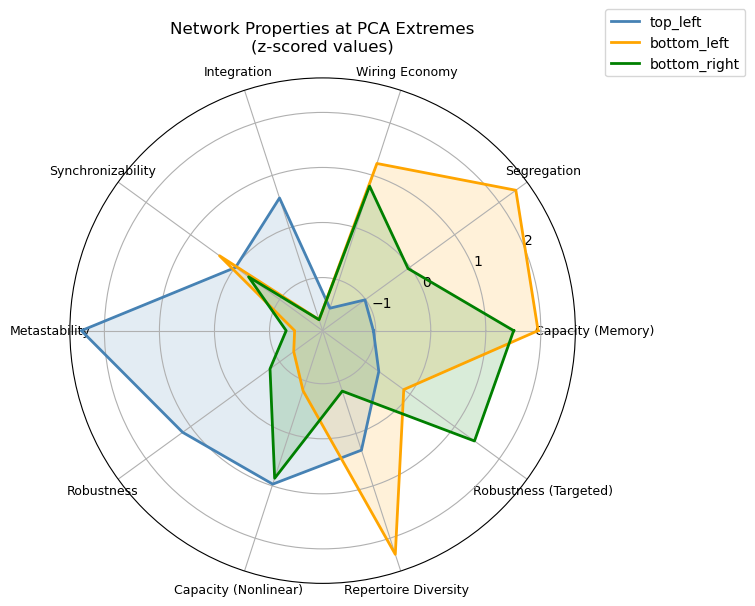

In [111]:
# ── STEP 2: Use predefined representatives ────────────────────────────────────

REPRESENTATIVES_FOR_GOALS = {
    'mc_mean':                                          'Capacity (Memory)',
    'modularity':                                       'Segregation',
    'proportion_long_range_connections_0.3956':         'Wiring Economy',
    'global_efficiency':                                'Integration',
    'synchronizability_eigenratio_eigenratio':          'Synchronizability',
    'kuramoto_synchronization_r_std':                   'Metastability',
    'algebraic_connectivity_nx':                        'Robustness',
    'computational_capacity_nonlinear_capacity_total':  'Capacity (Nonlinear)',
    'repertoire_sweep_weighted_by_distances_diversity_critical': 'Repertoire Diversity',
    'targeted_attack_robustness_rob_targeted_auc':      'Robustness (Targeted)',
}

rep_keys = list(REPRESENTATIVES_FOR_GOALS.keys())
rep_labels = list(REPRESENTATIVES_FOR_GOALS.values())

# Get column indices in pca_df (scaled_data columns match pca_df.columns)
rep_idx = [pca_df.columns.get_loc(k) for k in rep_keys]

# ── STEP 3: Extract standardized values for each corner ───────────────────────

corner_data = {
    name: scaled_data[idx, rep_idx]
    for name, idx in corners.items()
}

# ── STEP 4: Spider plot ────────────────────────────────────────────────────────

n = len(rep_labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

colors = {"top_left": "steelblue", 
          "bottom_left": "orange",
          "right": "brown",
          "bottom_right": "green"
          }

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, values in corner_data.items():
    vals = values.tolist() + [values[0]]
    ax.plot(angles, vals, label=name, color=colors[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=colors[name])

ax.set_thetagrids(np.degrees(angles[:-1]), rep_labels, fontsize=9)
ax.set_title("Network Properties at PCA Extremes\n(z-scored values)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()

In [89]:
# # Get all column names
# all_columns = pca_input_df.columns.tolist()

# # Filter out excluded columns
# feature_columns = [col for col in all_columns] # if col not in exclude_columns]

# # Filter out non-numerical columns
# feature_columns = [col for col in feature_columns if pd.api.types.is_numeric_dtype(pca_input_df[col])]

# # Filter out constant columns
# feature_columns = [col for col in feature_columns if pca_input_df[col].nunique() > 1]

# # Filter out columns starting with "h_params" (if they exist)
# feature_columns = [col for col in feature_columns if not col.startswith("h_params")]


# print(f"\nTotal columns: {len(all_columns)}")
# # print(f"Excluded columns: {len(exclude_columns)}")
# print(f"Feature columns for PCA: {len(feature_columns)}")

# # Extract features for PCA
# X = pca_input_df[feature_columns].copy()

# # Handle missing values
# print(f"\nMissing values before handling: {X.isnull().sum().sum()}")
# # Print in which columns values are missing 
# missing_cols = X.columns[X.isnull().any()].tolist()
# print(f"Columns with missing values: {missing_cols}")

# # !!!!!!!!!!!!!!!!!
# # Exclude these columns from PCA FOR NOW!!!! 
# X = X.drop(columns=missing_cols)

# # # X = X.fillna(X.mean())  # Fill NaN with column mean
# # print(f"Missing values after handling: {X.isnull().sum().sum()}")

# # Print how many pos / neg inf values there are in the dataset (if any), and in which columns they are
# inf_cols = X.columns[(X == np.inf).any() | (X == -np.inf).any()].tolist()
# inf_count_pos = (X == np.inf).sum().sum()
# inf_count_neg = (X == -np.inf).sum().sum()
# print(f"\nNumber of positive infinite values in the dataset: {inf_count_pos}")
# print(f"Number of negative infinite values in the dataset: {inf_count_neg}")
# print(f"Columns with infinite values: {inf_cols}")
# # !!!!!!!!!!!!!!!!!
# # FOR NOW: Exclude these columns from PCA as well, since they contain infinite values.
# X = X.drop(columns=inf_cols)


# # # Handle infinite values
# # X = X.replace([np.inf, -np.inf], np.nan)
# # X = X.fillna(X.mean())

# # # Drop columns that are all NaN (if any remain)
# # X = X.dropna(axis=1, how='all')

# # Update feature_columns to match the cleaned data
# feature_columns_cleaned = X.columns.tolist()

# print(f"\nFinal feature matrix shape: {X.shape}")
# print(f"Feature columns after cleaning: {len(feature_columns_cleaned)}")
# if len(feature_columns_cleaned) != len(feature_columns):
#     print(f"Note: {len(feature_columns) - len(feature_columns_cleaned)} columns were removed during cleaning")


### Only empirical and optimal datasets

In [90]:
# fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18,6), dpi=100)
# for i in range(2):
#     axs[i].barh(range(num_metrics), loadings[:, i])
#     axs[i].set_yticks(range(num_metrics))
#     axs[i].set_yticklabels(metric_names, rotation=0)
#     axs[i].set_title(f"Loadings for PC{i+1}")

# # Plot 3: Addition of PC1 and PC2, ordered by magnitude of PC1+PC2
# ordered_pc1_plus_pc2_indices = np.argsort(np.abs(loadings[:, 0] + loadings[:, 1])) #[::-1]
# loadings = loadings[ordered_pc1_plus_pc2_indices]
# metric_names = metric_names[ordered_pc1_plus_pc2_indices]
# axs[2].barh(range(num_metrics), loadings[:, 0] + loadings[:, 1], color="orange")
# axs[2].set_yticks(range(num_metrics))
# axs[2].set_yticklabels(metric_names, rotation=0)
# axs[2].set_title("Loadings for PC1 + PC2")

# plt.tight_layout()
# plt.show()


In [91]:
huge_df["dataset"]

0        hcp_schaefer_100_dataset_gnm
1        hcp_schaefer_100_dataset_gnm
2        hcp_schaefer_100_dataset_gnm
3        hcp_schaefer_100_dataset_gnm
4        hcp_schaefer_100_dataset_gnm
                     ...             
25322             suarez_MaMI_dataset
25323             suarez_MaMI_dataset
25324             suarez_MaMI_dataset
25325             suarez_MaMI_dataset
25326             suarez_MaMI_dataset
Name: dataset, Length: 25327, dtype: object

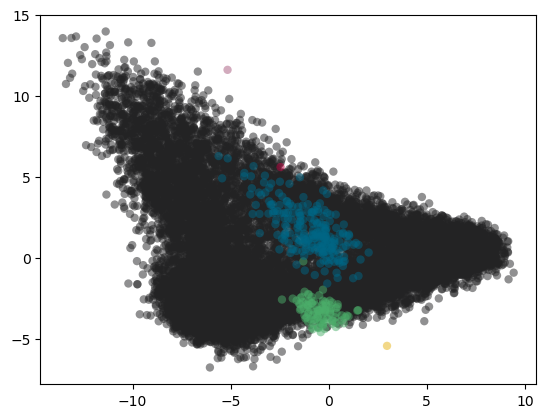

In [ ]:
pca_input_df_label['dataset'].unique()

        # COLOR_SCHEME[pca_input_df_label['dataset']]

# sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], c=[COLOR_SCHEME[c] for c in pca_input_df_label['dataset']])
plt.scatter(x=pca_result[:,0], y=pca_result[:,1], c=[COLOR_SCHEME[c] for c in pca_input_df_label['dataset']], alpha=0.5, edgecolors="none")

Corner points:
  top_left: index=102, PC1=-5.16, PC2=11.60, dataset=kaysons_generated_networks_routing
  bottom_left: index=67, PC1=-0.82, PC2=-4.43, dataset=hcp_schaefer_100_dataset
  bottom_right: index=100, PC1=2.97, PC2=-5.45, dataset=kaysons_generated_networks_diffusion


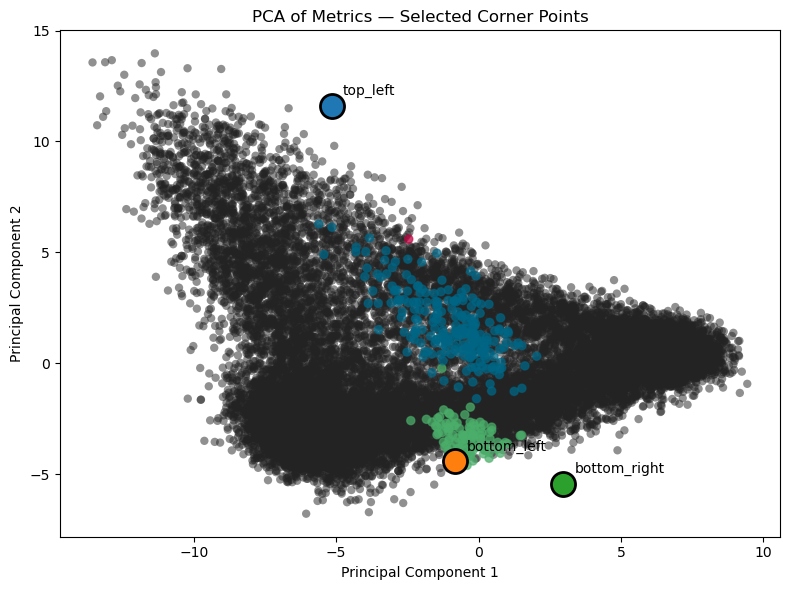


Top 6 features by PC1+PC2 loading magnitude:
  nct_energies_n_nodes_50_percent: 0.3144
  energy: 0.2856
  topological_distance_mean: 0.2824
  avg_communicability: 0.2664
  degree_assortativity: 0.2529
  nct_energies_n_nodes_90_percent: 0.2438


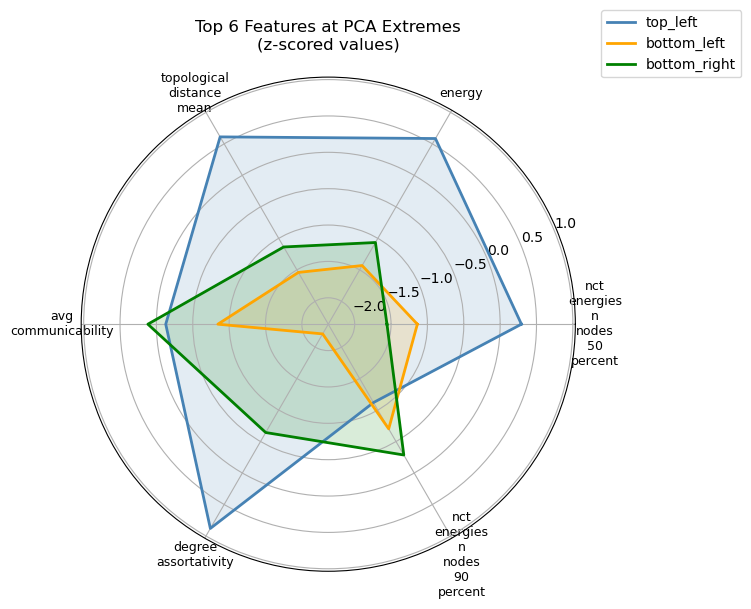

In [104]:

# ── STEP 1: Find the 3 extreme corner points ──────────────────────────────────


# For pca always drop the dataset column and only use the metric columns
# pca_df_with_dataset_label = huge_df[remaining_cols+["dataset"]]

# Get all datasets except for the "_gnm" one. Get the corresponding PCA results for those datasets only. 
pca_df_only_emp_and_opt = pca_input_df_label[pca_input_df_label['dataset'] != "hcp_schaefer_100_dataset_gnm"]
pca_df_only_emp_and_opt_prop = pca_df_only_emp_and_opt.drop(columns="dataset") 
# pca_result_only_emp_and_opt = pca.fit_transform(scaler.fit_transform(pca_df_only_emp_and_opt_prop))
pca_result_only_emp_and_opt = pca_result[pca_input_df_label['dataset'] != "hcp_schaefer_100_dataset_gnm", :]

corners = {
    "top_left":    np.argmax(pca_result_only_emp_and_opt[:, 1]),                              # max PC2
    "bottom_left": np.argmax(-pca_result_only_emp_and_opt[:, 0] - pca_result_only_emp_and_opt[:, 1]),         # min PC1 + min PC2
    # "right":       np.argmax(pca_result[:, 0]),       # max PC1
    "bottom_right": np.argmax(pca_result_only_emp_and_opt[:, 0] - pca_result_only_emp_and_opt[:, 1]),         # max PC1 + min PC2
}

print("Corner points:")
for name, idx in corners.items():
    print(f"  {name}: index={idx}, PC1={pca_result_only_emp_and_opt[idx,0]:.2f}, PC2={pca_result_only_emp_and_opt[idx,1]:.2f}, "
          f"dataset={pca_df_only_emp_and_opt['dataset'].iloc[idx]}")

# Verify visually
plt.figure(figsize=(8, 6))
# sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=pca_input_df_label['dataset'], alpha=0.5)
                # , hue="gray", 
                # alpha=0.5)
                
plt.scatter(x=pca_result[:,0], 
            y=pca_result[:,1], 
            c=[COLOR_SCHEME[c] for c in pca_input_df_label['dataset']],
            label=pca_input_df_label["dataset"], 
            alpha=0.5, edgecolors="none")
plt.scatter(x=pca_result_only_emp_and_opt[:,0], 
            y=pca_result_only_emp_and_opt[:,1], 
            c=[COLOR_SCHEME[c] for c in pca_df_only_emp_and_opt['dataset']], 
            alpha=0.5)

for name, idx in corners.items():
    plt.scatter(pca_result_only_emp_and_opt[idx, 0], pca_result_only_emp_and_opt[idx, 1], s=300, zorder=5, edgecolors='black', linewidths=2)
    plt.annotate(name, (pca_result_only_emp_and_opt[idx, 0], pca_result_only_emp_and_opt[idx, 1]), textcoords="offset points", xytext=(8, 8), fontsize=10)
plt.title("PCA of Metrics — Selected Corner Points")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# ── STEP 2: Get the top 6 features by loading magnitude (PC1 + PC2) ───────────

feature_names = pca_df_only_emp_and_opt_prop.columns  # from your pipeline: pca_df = pca_df_with_dataset_label.drop(columns="dataset")  
loading_magnitude = np.sqrt(pca.components_[0]**2 + pca.components_[1]**2)
top6_idx = np.argsort(loading_magnitude)[::-1][:6]
top6_features = feature_names[top6_idx]

print("\nTop 6 features by PC1+PC2 loading magnitude:")
for feat, mag in zip(top6_features, loading_magnitude[top6_idx]):
    print(f"  {feat}: {mag:.4f}")

# ── STEP 3: Extract standardized values for each corner ───────────────────────

corner_data = {
    name: scaled_data[idx, top6_idx]
    for name, idx in corners.items()
}


# ── STEP 4: Spider plot ────────────────────────────────────────────────────────

labels = [f.replace("_", "\n") for f in top6_features]  # wrap long names
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]

colors = {"top_left": "steelblue", 
          "bottom_left": "orange", 
          "right": "brown", 
          "bottom_right": "green"
          }  

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, values in corner_data.items():
    vals = values.tolist() + [values[0]]
    ax.plot(angles, vals, label=name, color=colors[name], linewidth=2)
    ax.fill(angles, vals, alpha=0.15, color=colors[name])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9)
ax.set_title("Top 6 Features at PCA Extremes\n(z-scored values)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15))
plt.tight_layout()
plt.show()